# Medical insurance cost prediction

## Project objective

The objective of this supervised machine learning regression project is to predict medical insurance charges based on patient attributes such as age, sex, BMI, number of children, smoking status, and region.

The project will include raw data inspection, exploratory data analysis, preprocessing, model training, model evaluation, overfitting checks, tuning, and final model deployment using Streamlit.

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("Health_Insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Raw dataset inspection

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

print("\nSummary statistics for numerical columns:")
display(df.describe())

# Identify categorical columns safely
categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

print("\nCategorical columns:")
print(categorical_cols)

print("\nSummary statistics for categorical columns:")
if len(categorical_cols) > 0:
    display(df[categorical_cols].describe())
else:
    print("No categorical columns found.")

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nUnique values in categorical columns:")

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

Dataset shape:
(1338, 7)

Column names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB

Summary statistics for numerical columns:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



Categorical columns:
['sex', 'smoker', 'region']

Summary statistics for categorical columns:


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364



Missing values:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


Duplicate rows:
1

Unique values in categorical columns:

sex:
sex
male      676
female    662
Name: count, dtype: int64

smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [4]:
# Data quality cleanup

df_clean = df.copy()

print("Shape before cleanup:")
print(df_clean.shape)

print("\nDuplicate rows before cleanup:")
print(df_clean.duplicated().sum())

# Remove duplicate rows
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("\nShape after duplicate removal:")
print(df_clean.shape)

print("\nDuplicate rows after cleanup:")
print(df_clean.duplicated().sum())

print("\nMissing values after cleanup:")
display(df_clean.isnull().sum())

print("\nFinal data types after cleanup:")
display(df_clean.dtypes)

Shape before cleanup:
(1338, 7)

Duplicate rows before cleanup:
1

Shape after duplicate removal:
(1337, 7)

Duplicate rows after cleanup:
0

Missing values after cleanup:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


Final data types after cleanup:


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

## Raw dataset inspection summary

The dataset contains medical insurance records with 7 columns: `age`, `sex`, `bmi`, `children`, `smoker`, `region`, and `charges`.

After raw inspection:

- The original dataset had 1,338 rows and 7 columns.
- One duplicate row was found and removed.
- The cleaned dataset now has 1,337 rows and 7 columns.
- There are no missing values in any column.
- The target variable is `charges`, which is continuous, so this is a supervised machine learning regression problem.
- Numerical input features are `age`, `bmi`, and `children`.
- Categorical input features are `sex`, `smoker`, and `region`.

Key initial observations:

- `charges` ranges from about 1,122 to 63,770, showing a wide spread in insurance costs.
- The mean charge is around 13,270, while the median charge is around 9,382. Since the mean is much higher than the median, the target variable is likely right-skewed.
- `bmi` ranges from about 15.96 to 53.13, so BMI outliers or high-BMI cases need to be checked carefully.
- `smoker` is imbalanced: most records are non-smokers, while smokers form a smaller group.
- Region distribution is fairly balanced, with the southeast region having slightly more records.
- Sex distribution is also fairly balanced.

Data quality decision:

No missing value treatment is required. The duplicate row was removed before EDA and model training. Potential outliers in `charges` and `bmi` will be investigated during EDA, but high medical charges should not be removed blindly because they may represent valid and business-important insurance cases.

----

## EDA 1: Target variable distribution

The target variable for this project is `charges`, which represents the medical insurance cost billed for each individual.

In this step, we inspect the distribution of `charges` to understand:
- Whether the target is normally distributed or skewed
- Whether high-cost records exist
- Whether log transformation may be useful during model building

Target variable summary:


count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64


Target variable skewness:
1.5153909108403483

Selected percentiles for charges:


0.01     1252.957440
0.05     1767.492920
0.25     4746.344000
0.50     9386.161300
0.75    16657.717450
0.90    34832.741600
0.95    41210.049800
0.99    48537.796878
Name: charges, dtype: float64


Mean charges:
13279.121486655948

Median charges:
9386.1613


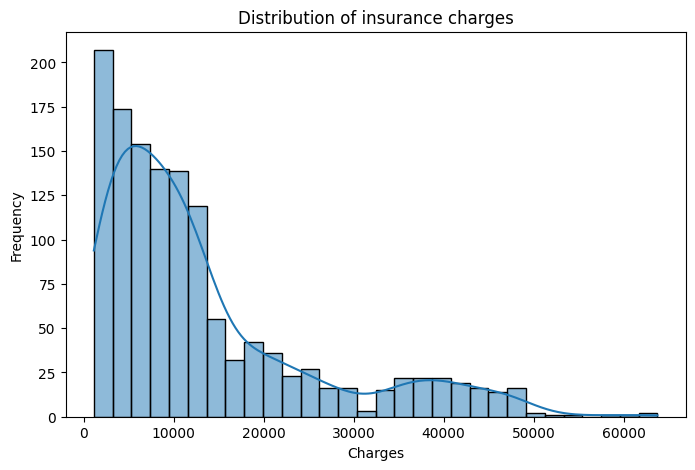

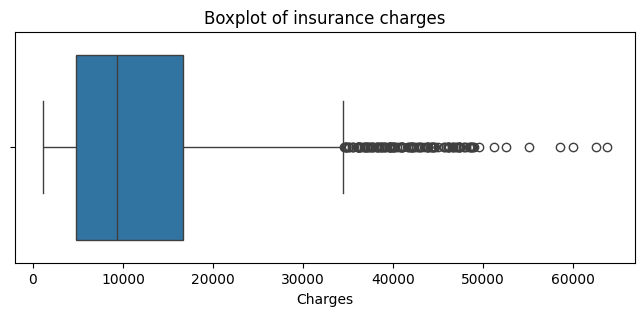

In [5]:
target_col = "charges"

print("Target variable summary:")
display(df_clean[target_col].describe())

print("\nTarget variable skewness:")
print(df_clean[target_col].skew())

print("\nSelected percentiles for charges:")
display(df_clean[target_col].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

print("\nMean charges:")
print(df_clean[target_col].mean())

print("\nMedian charges:")
print(df_clean[target_col].median())

plt.figure(figsize=(8, 5))
sns.histplot(df_clean[target_col], kde=True, bins=30)
plt.title("Distribution of insurance charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 3))
sns.boxplot(x=df_clean[target_col])
plt.title("Boxplot of insurance charges")
plt.xlabel("Charges")
plt.show()

### Target variable insights: `charges`

The target variable `charges` is right-skewed.

Key observations:

- The average insurance charge is around 13,279, while the median is around 9,386.
- Since the mean is much higher than the median, the distribution is pulled upward by high-cost cases.
- The skewness value is approximately 1.52, confirming a strong right-skew.
- Most insurance charges are concentrated below 15,000.
- A smaller number of records have much higher charges, extending up to around 63,770.
- The boxplot shows several high-value points on the upper side, but these should not be removed blindly because high medical costs can be valid and business-important.

Modeling decision:

The skewed nature of `charges` suggests that we should later compare two modeling approaches:

1. Predicting the original `charges` directly.
2. Predicting log-transformed `charges` and converting predictions back to the original scale.

This will help us check whether log transformation improves model performance and reduces the impact of extreme high-cost cases.

----

## EDA 2: Numerical feature distributions

In this step, we inspect the distribution of numerical input features: `age`, `bmi`, and `children`.

This helps us understand:
- Whether numerical features are evenly distributed or skewed
- Whether BMI has unusually high or low values
- Whether the number of children has a limited/discrete distribution
- Whether feature scaling may be needed before model training

Numerical feature summary:


,age,bmi,children
count,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737
std,14.044333,6.100468,1.205571
min,18.000000,15.960000,0.000000
25%,27.000000,26.290000,0.000000
50%,39.000000,30.400000,1.000000
75%,51.000000,34.700000,2.000000
max,64.000000,53.130000,5.000000



Skewness of numerical features:


children    0.937421
bmi         0.283914
age         0.054781
dtype: float64

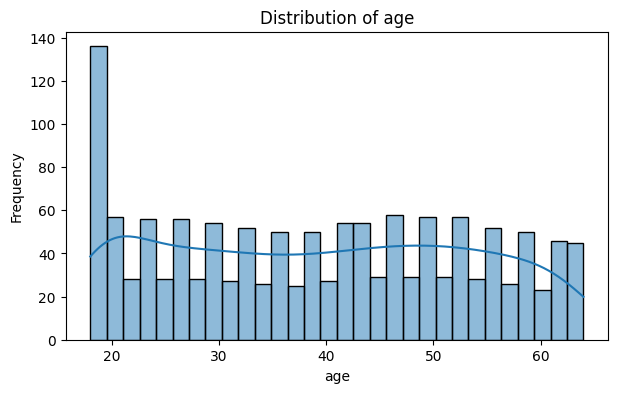

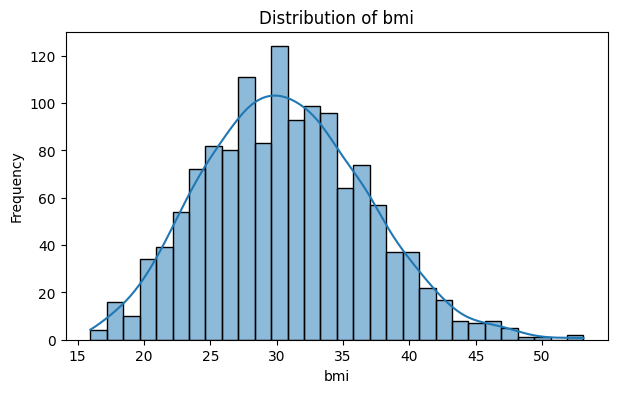

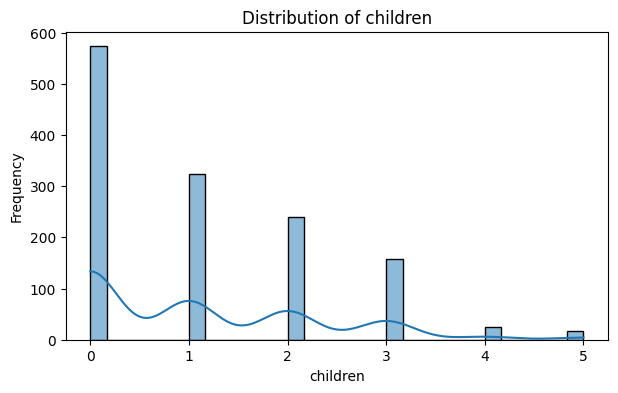

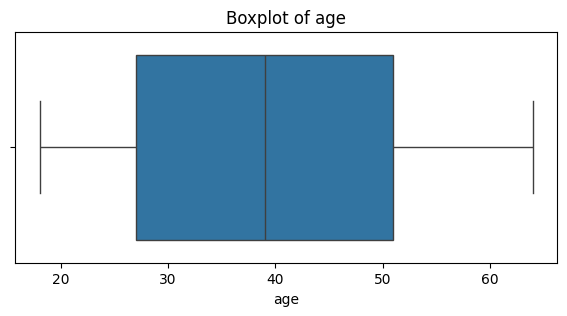

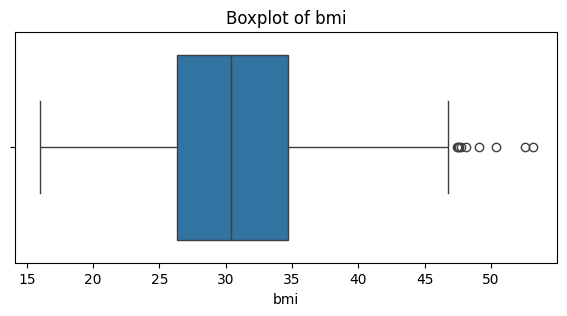

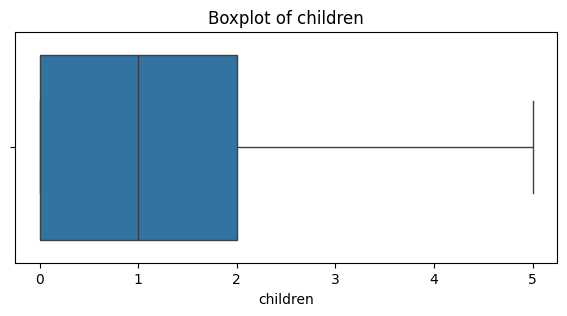

In [6]:
numerical_features = ["age", "bmi", "children"]

print("Numerical feature summary:")
display(df_clean[numerical_features].describe())

print("\nSkewness of numerical features:")
display(df_clean[numerical_features].skew().sort_values(ascending=False))

for col in numerical_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(df_clean[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

for col in numerical_features:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

### Numerical feature distribution insights

The numerical input features are `age`, `bmi`, and `children`.

Key observations:

- `age` ranges from 18 to 64 years, with an average age of around 39 years.
- The age distribution is fairly spread across the adult age range, with very low skewness of around 0.06.
- `bmi` ranges from about 15.96 to 53.13, with an average BMI of around 30.66.
- BMI is slightly right-skewed, with skewness around 0.28, but the distribution is broadly close to normal.
- The BMI boxplot shows a few high-BMI values above the upper whisker. These should not be removed automatically because they may represent valid patient profiles.
- `children` ranges from 0 to 5, with most policyholders having 0, 1, or 2 children.
- The `children` variable is right-skewed, with skewness around 0.94, because fewer records have 3 or more children.
- No major issue is visible in the `age` distribution.
- BMI and charges will need careful outlier analysis before deciding any treatment.

Modeling decision:

Feature scaling will be useful for distance-based and margin-based models such as KNN and SVR. Tree-based models such as Decision Tree, Random Forest, Gradient Boosting, and XGBoost do not require scaling, but using a preprocessing pipeline will keep the workflow consistent.

----

## EDA 3: Categorical feature distributions

In this step, we inspect the categorical input features: `sex`, `smoker`, and `region`.

This helps us understand:
- Whether category values are clean and expected
- Whether any category is highly imbalanced
- Whether categorical variables may influence insurance charges

Categorical feature counts and percentages:

SEX - Count:


sex
male      675
female    662
Name: count, dtype: int64

SEX - Percentage:


sex
male      50.49
female    49.51
Name: proportion, dtype: float64


SMOKER - Count:


...

smoker
no     79.51
yes    20.49
Name: proportion, dtype: float64


REGION - Count:


region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

REGION - Percentage:


region
southeast    27.23
southwest    24.31
northwest    24.23
northeast    24.23
Name: proportion, dtype: float64

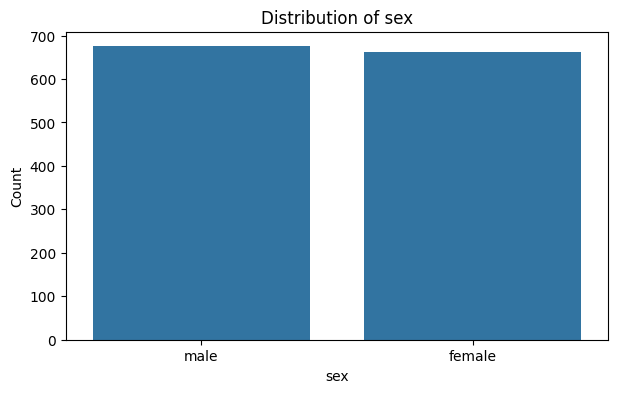

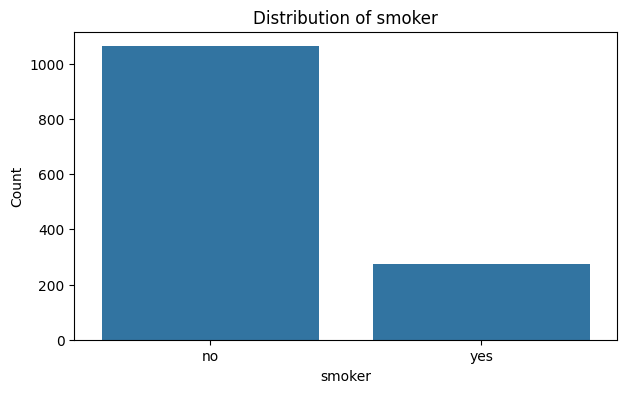

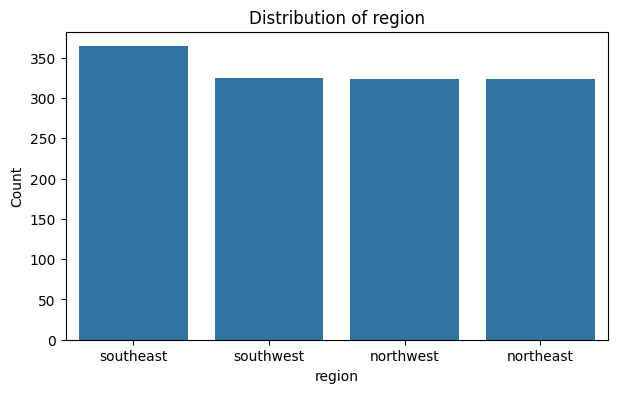

In [7]:
categorical_features = ["sex", "smoker", "region"]

print("Categorical feature counts and percentages:")

for col in categorical_features:
    print(f"\n{col.upper()} - Count:")
    display(df_clean[col].value_counts())
    
    print(f"{col.upper()} - Percentage:")
    display((df_clean[col].value_counts(normalize=True) * 100).round(2))

# Countplots for categorical features
for col in categorical_features:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df_clean, x=col, order=df_clean[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

### Categorical feature distribution insights

The categorical input features are `sex`, `smoker`, and `region`.

Key observations:

- The `sex` variable is almost evenly distributed, with males forming around 50.49% and females around 49.51% of the dataset.
- The `smoker` variable is imbalanced. Around 79.51% of records are non-smokers, while around 20.49% are smokers.
- This imbalance in `smoker` is important because smoking status is likely to have a strong relationship with medical insurance charges.
- The `region` variable is fairly balanced across the four regions.
- The southeast region has the highest count at around 27.23%, while the other three regions are each around 24.23% to 24.31%.
- No spelling inconsistencies or unexpected category values are visible in the categorical columns.

Modeling decision:

Categorical variables will need encoding before model training. Since `sex`, `smoker`, and `region` have a small number of clean categories, OneHotEncoder is suitable. The imbalance in `smoker` should not be treated like target class imbalance because this is a regression project, but its relationship with `charges` should be analyzed carefully during EDA.

----

## EDA 4: Insurance charges by categorical features

In this step, we compare medical insurance charges across categorical features: `smoker`, `sex`, and `region`.

This helps us understand:
- Whether smokers and non-smokers have different insurance charge patterns
- Whether charges differ meaningfully by sex
- Whether region has a visible relationship with insurance charges
- Which categorical features may become important predictors during model training


Charges summary by smoker:


,count,mean,median,min,max,std
smoker,,,,,,
yes,274,32050.23,34456.35,12829.46,63770.43,11541.55
no,1063,8440.66,7345.73,1121.87,36910.61,5992.97



Charges summary by sex:


,count,mean,median,min,max,std
sex,,,,,,
male,675,13975.00,9377.90,1121.87,62592.87,12971.96
female,662,12569.58,9412.96,1607.51,63770.43,11128.70



Charges summary by region:


,count,mean,median,min,max,std
region,,,,,,
southeast,364,14735.41,9294.13,1121.87,63770.43,13971.10
northeast,324,13406.38,10057.65,1694.80,58571.07,11255.80
northwest,324,12450.84,8976.98,1621.34,60021.40,11073.13
southwest,325,12346.94,8798.59,1241.56,52590.83,11557.18


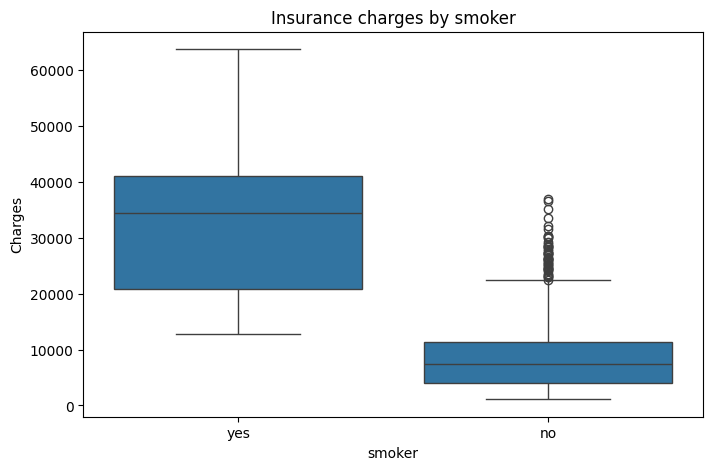

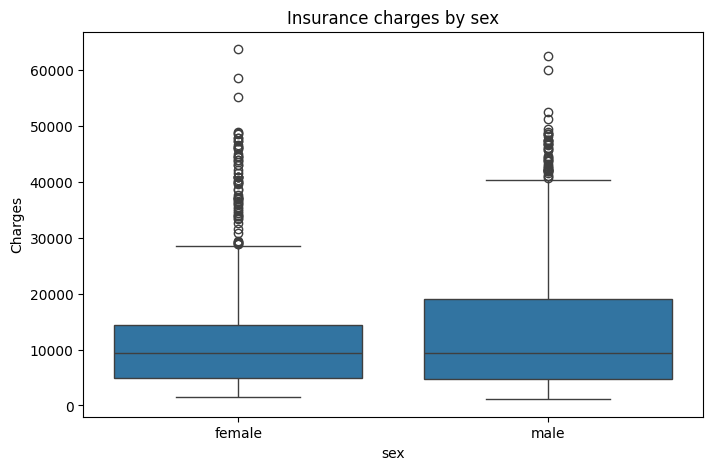

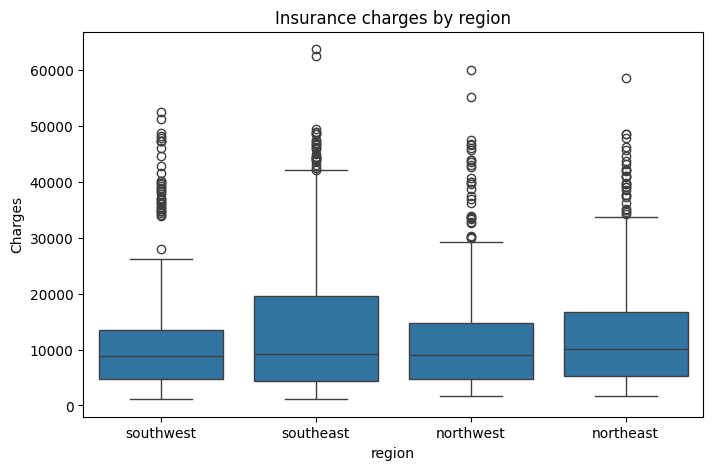

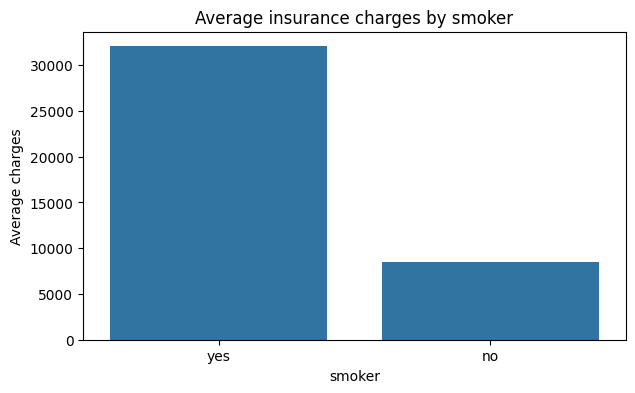

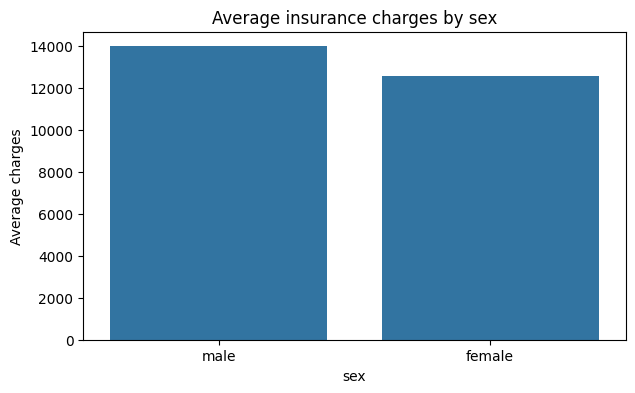

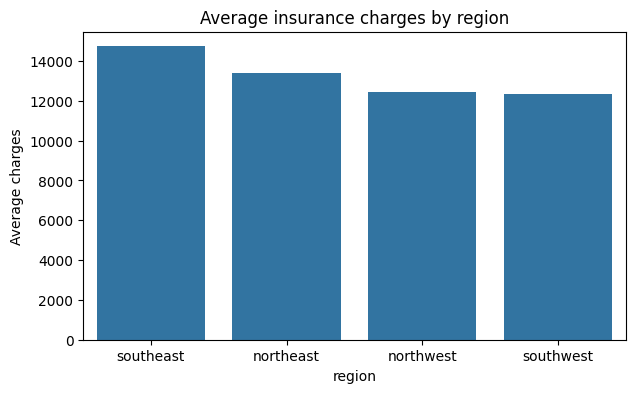

In [8]:
categorical_features = ["smoker", "sex", "region"]

for col in categorical_features:
    print(f"\nCharges summary by {col}:")
    
    summary = (
        df_clean
        .groupby(col)["charges"]
        .agg(
            count="count",
            mean="mean",
            median="median",
            min="min",
            max="max",
            std="std"
        )
        .sort_values(by="mean", ascending=False)
    )
    
    display(summary.round(2))

# Boxplots: charges by categorical features
for col in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_clean, x=col, y="charges")
    plt.title(f"Insurance charges by {col}")
    plt.xlabel(col)
    plt.ylabel("Charges")
    plt.show()

# Mean charges barplots
for col in categorical_features:
    mean_summary = (
        df_clean
        .groupby(col)["charges"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    
    plt.figure(figsize=(7, 4))
    sns.barplot(data=mean_summary, x=col, y="charges")
    plt.title(f"Average insurance charges by {col}")
    plt.xlabel(col)
    plt.ylabel("Average charges")
    plt.show()

### Charges by categorical feature insights

This section compares medical insurance charges across categorical features: `smoker`, `sex`, and `region`.

Key observations:

- Smoking status shows the strongest difference in insurance charges.
- Smokers have an average charge of around 32,050, while non-smokers have an average charge of around 8,441.
- The median charge for smokers is also much higher, around 34,456, compared to around 7,346 for non-smokers.
- This indicates that `smoker` is likely to be one of the strongest predictors of insurance charges.

Sex-based comparison:

- Males have a slightly higher average charge of around 13,975 compared to females at around 12,570.
- However, the median values are very close: around 9,378 for males and 9,412 for females.
- This suggests that the average difference may be influenced by high-cost outliers rather than a strong direct relationship.
- Sex should be used only as a model input, not as a standalone basis for business recommendations.

Region-based comparison:

- The southeast region has the highest average insurance charge at around 14,735.
- The southwest region has the lowest average charge at around 12,347.
- The median values across regions are relatively close, so the regional difference may not be very strong.
- Region should be interpreted carefully because differences may be influenced by other factors such as smoker distribution, BMI, or age mix within each region.

Management insight:

Smoking status appears to be a major cost driver and should be explored further with BMI and age. Region and sex show some variation, but they should not be over-interpreted without checking interactions with other variables.

---

## EDA 5: Insurance charges by numerical segments

In this step, we analyze how medical insurance charges vary across numerical feature segments.

We create temporary EDA segments for:

- Age groups
- BMI categories
- Number of children

This helps identify high-cost customer segments and supports management-level recommendations later in the project.

Charges summary by age group:


,count,mean,median,min,max,std
age_group,,,,,,
18-25,305,9111.43,2639.04,1121.87,44501.40,11768.31
26-35,268,10495.16,4900.58,2302.30,58571.07,11349.44
36-45,264,13493.49,7442.57,4399.73,62592.87,12096.98
46-55,284,15986.90,10477.96,7147.10,63770.43,11367.40
56-64,216,18795.99,13429.65,10577.09,52590.83,11482.26



Charges summary by BMI category:


,count,mean,median,min,max,std
bmi_category,,,,,,
Underweight,21,8657.62,6640.54,1621.34,32734.19,7591.73
Normal,226,10435.44,8604.15,1121.87,35069.37,7484.43
Overweight,386,10997.80,8659.38,1252.41,38245.59,8067.25
Obese I,388,14462.38,9573.46,1131.51,62592.87,13591.84
Obese II+,316,16953.82,10903.91,1141.45,63770.43,15587.68



Charges summary by number of children:


,count,mean,median,min,max,std
children,,,,,,
0,573,12384.70,9863.47,1121.87,63770.43,12025.42
1,324,12731.17,8483.87,1711.03,58571.07,11823.63
2,240,15073.56,9264.98,2304.00,49577.66,12891.37
3,157,15355.32,10600.55,3443.06,60021.40,12330.87
4,25,13850.66,11033.66,4504.66,40182.25,9139.22
5,18,8786.04,8589.57,4687.80,19023.26,3808.44


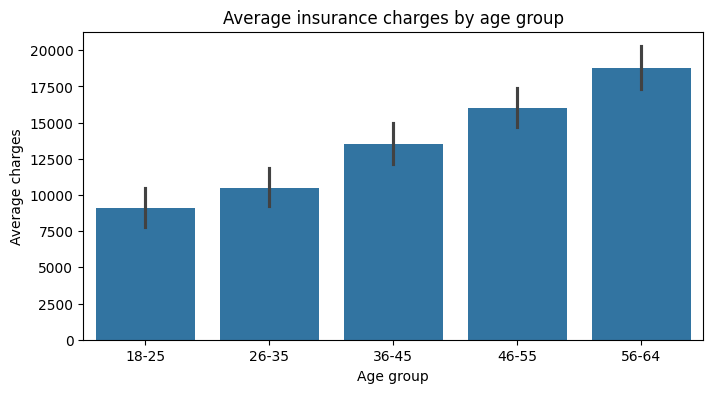

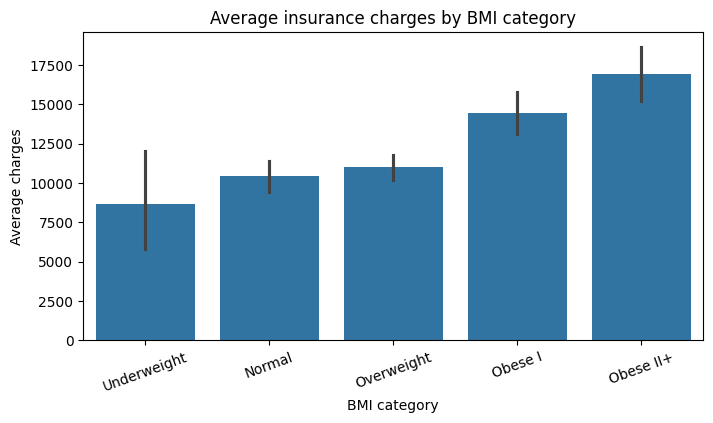

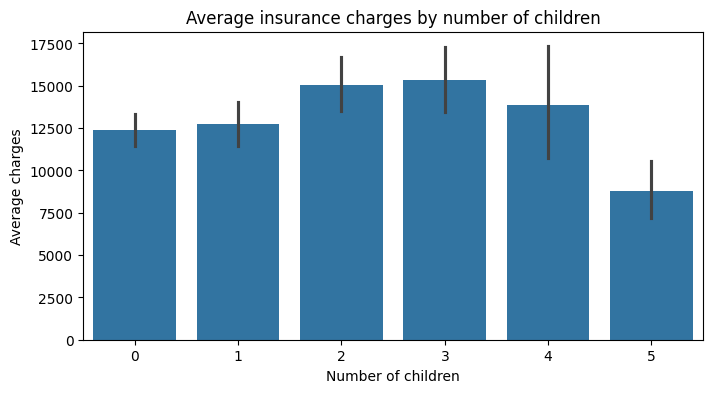

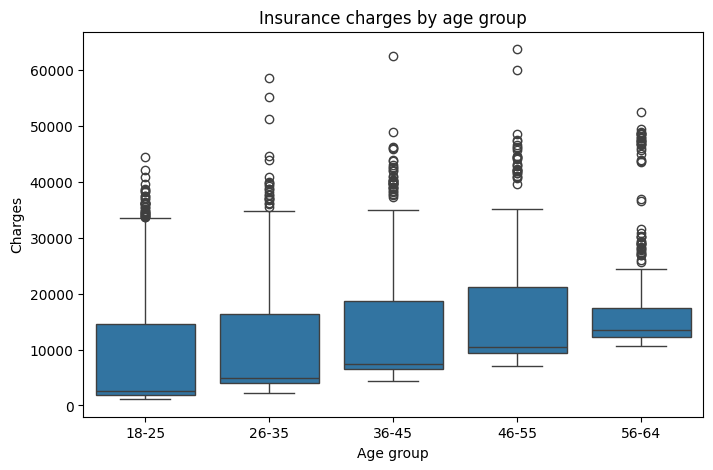

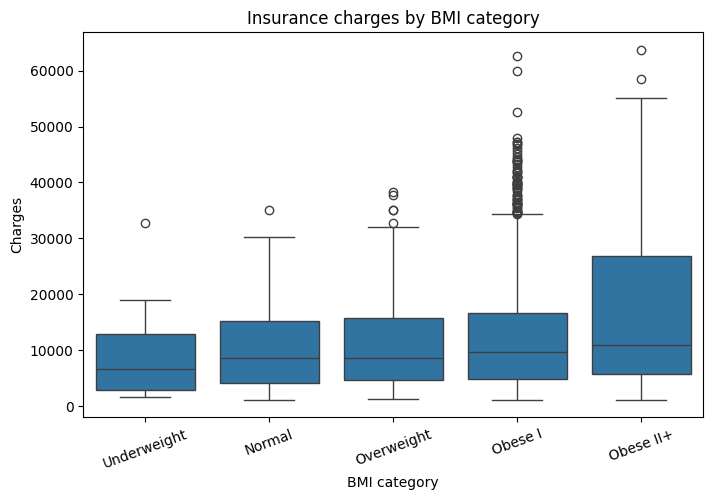

In [9]:
df_eda = df_clean.copy()

# Create age groups
df_eda["age_group"] = pd.cut(
    df_eda["age"],
    bins=[17, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-64"]
)

# Create BMI categories using common BMI ranges
df_eda["bmi_category"] = pd.cut(
    df_eda["bmi"],
    bins=[0, 18.5, 25, 30, 35, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese I", "Obese II+"]
)

# Charges summary by age group
print("Charges summary by age group:")
age_summary = (
    df_eda
    .groupby("age_group", observed=False)["charges"]
    .agg(count="count", mean="mean", median="median", min="min", max="max", std="std")
)
display(age_summary.round(2))

print("\nCharges summary by BMI category:")
bmi_summary = (
    df_eda
    .groupby("bmi_category", observed=False)["charges"]
    .agg(count="count", mean="mean", median="median", min="min", max="max", std="std")
)
display(bmi_summary.round(2))

print("\nCharges summary by number of children:")
children_summary = (
    df_eda
    .groupby("children")["charges"]
    .agg(count="count", mean="mean", median="median", min="min", max="max", std="std")
)
display(children_summary.round(2))

plt.figure(figsize=(8, 4))
sns.barplot(data=df_eda, x="age_group", y="charges", estimator=np.mean)
plt.title("Average insurance charges by age group")
plt.xlabel("Age group")
plt.ylabel("Average charges")
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=df_eda, x="bmi_category", y="charges", estimator=np.mean)
plt.title("Average insurance charges by BMI category")
plt.xlabel("BMI category")
plt.ylabel("Average charges")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=df_eda, x="children", y="charges", estimator=np.mean)
plt.title("Average insurance charges by number of children")
plt.xlabel("Number of children")
plt.ylabel("Average charges")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda, x="age_group", y="charges")
plt.title("Insurance charges by age group")
plt.xlabel("Age group")
plt.ylabel("Charges")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda, x="bmi_category", y="charges")
plt.title("Insurance charges by BMI category")
plt.xlabel("BMI category")
plt.ylabel("Charges")
plt.xticks(rotation=20)
plt.show()

### Charges by numerical segment insights

This section analyzes insurance charges across age groups, BMI categories, and number of children.

Age group insights:

- Average insurance charges increase steadily with age.
- The 18–25 age group has the lowest average charge at around 9,111.
- The 56–64 age group has the highest average charge at around 18,796.
- Median charges also increase with age, showing that age has a meaningful relationship with insurance cost.
- The boxplot shows high-cost records across all age groups, but older age groups have higher typical charge levels.

BMI category insights:

- Average charges generally increase as BMI category increases.
- The Obese II+ group has the highest average charge at around 16,954.
- Obese I also has a higher average charge than Normal and Overweight groups.
- The BMI boxplot shows several high-charge records in obese categories, suggesting BMI may interact with other cost drivers such as smoking.
- Underweight has only 21 records, so it should not be over-interpreted.

Children insights:

- Insurance charges do not show a simple increasing pattern with the number of children.
- Customers with 2 or 3 children have relatively higher average charges.
- Customers with 5 children show lower average charges, but this group has only 18 records, so the result is not reliable for strong conclusions.
- The `children` feature may still be useful for modeling, but it does not appear to be as strong a cost driver as age, BMI, or smoker status.

Management insight:

Age and BMI show meaningful cost patterns and should be included in the model. Smoking status still appears to be the strongest cost driver from earlier EDA, so the next important analysis is to check whether high charges are concentrated among smokers with higher BMI or older age.

----

## EDA 6: Correlation and interaction checks

In this step, we check the relationship between input features and insurance charges.

We analyze:
- Correlation between numerical variables and `charges`
- Relationship between age, BMI, smoking status, and charges
- Whether smokers with higher BMI or older age show higher cost patterns

This helps us identify important cost drivers before model building.

Correlation with charges:


charges           1.000
smoker_encoded    0.787
age               0.298
bmi               0.198
children          0.067
sex_encoded       0.058
Name: charges, dtype: float64

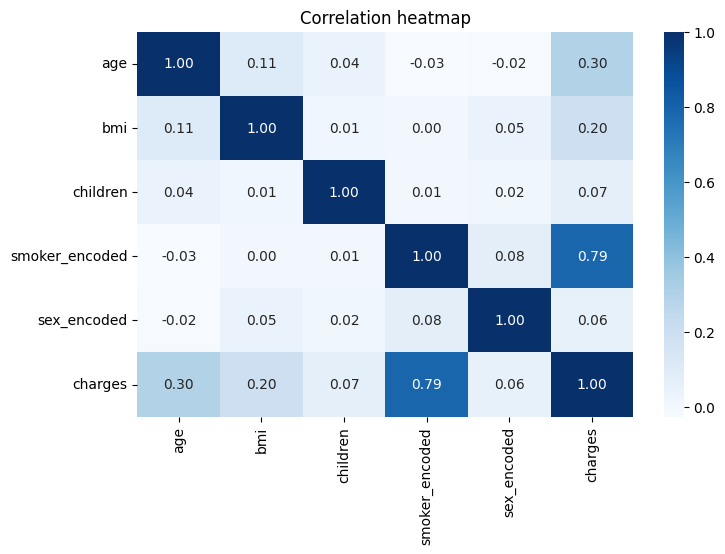


Average charges by smoker and BMI category:


,smoker,bmi_category,count,mean,median
0,no,Underweight,16,5485.06,4249.32
1,no,Normal,176,7734.65,6669.48
2,no,Overweight,311,8226.09,7046.72
3,no,Obese I,315,8571.89,7682.67
4,no,Obese II+,245,9244.50,8527.53
5,yes,Underweight,5,18809.82,15006.58
6,yes,Normal,50,19942.22,19479.90
7,yes,Overweight,75,22491.18,21348.71
8,yes,Obese I,73,39880.27,39125.33
9,yes,Obese II+,71,43556.40,42969.85



Average charges by smoker and age group:


,smoker,age_group,count,mean,median
0,no,18-25,240,4013.78,2209.41
1,no,26-35,212,5796.84,4528.33
2,no,36-45,203,7822.87,7144.86
3,no,46-55,232,11692.79,10068.73
4,no,56-64,176,14087.58,12982.11
5,yes,18-25,65,27933.56,33750.29
6,yes,26-35,56,28281.65,20865.04
7,yes,36-45,61,32364.54,37829.72
8,yes,46-55,52,35145.25,40847.36
9,yes,56-64,40,39513.00,45359.58


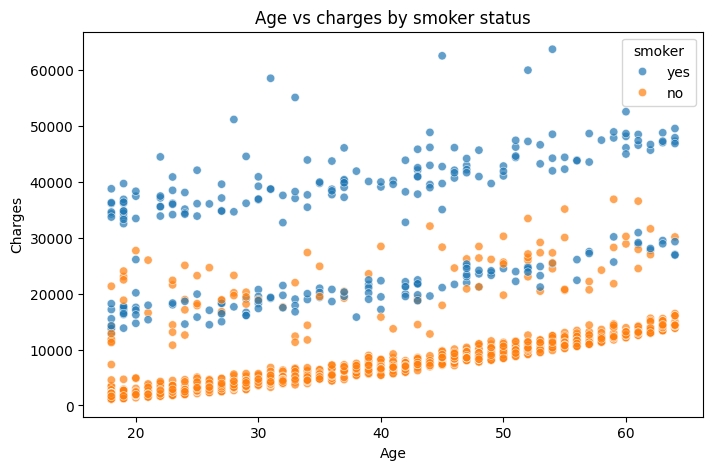

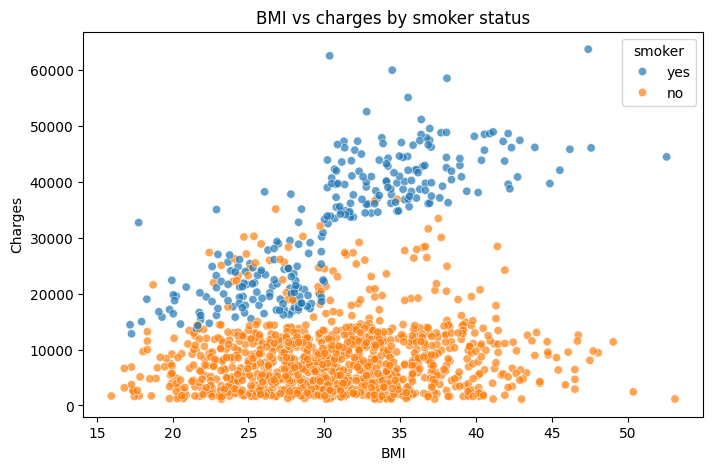

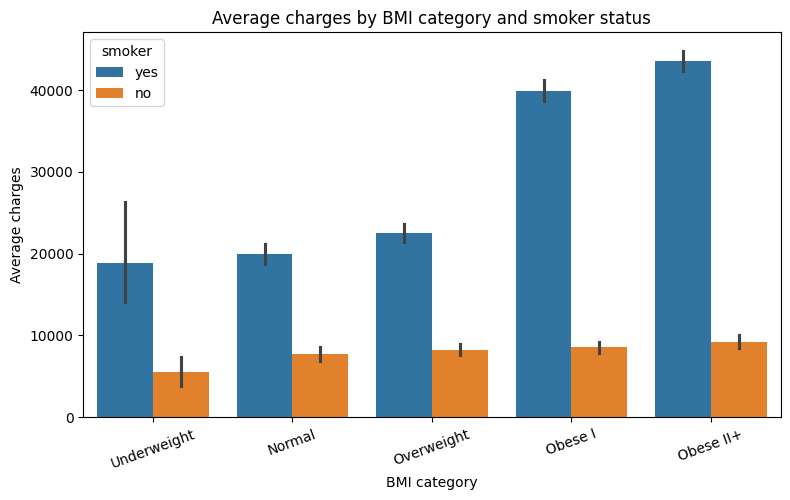

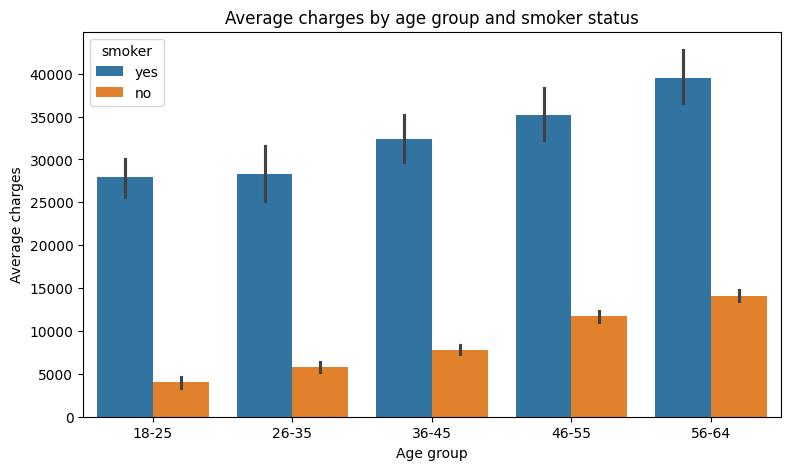

In [10]:
df_eda = df_clean.copy()

# Encode smoker and sex temporarily only for correlation analysis
df_eda["smoker_encoded"] = df_eda["smoker"].map({"no": 0, "yes": 1})
df_eda["sex_encoded"] = df_eda["sex"].map({"female": 0, "male": 1})

# Create age groups
df_eda["age_group"] = pd.cut(
    df_eda["age"],
    bins=[17, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-64"]
)

# Create BMI categories
df_eda["bmi_category"] = pd.cut(
    df_eda["bmi"],
    bins=[0, 18.5, 25, 30, 35, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese I", "Obese II+"]
)

# Correlation table
correlation_features = ["age", "bmi", "children", "smoker_encoded", "sex_encoded", "charges"]

print("Correlation with charges:")
display(
    df_eda[correlation_features]
    .corr(numeric_only=True)["charges"]
    .sort_values(ascending=False)
    .round(3)
)

# Correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    df_eda[correlation_features].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="Blues"
)
plt.title("Correlation heatmap")
plt.show()

# Charges by smoker and BMI category
print("\nAverage charges by smoker and BMI category:")
smoker_bmi_summary = (
    df_eda
    .groupby(["smoker", "bmi_category"], observed=False)["charges"]
    .agg(count="count", mean="mean", median="median")
    .reset_index()
)

display(smoker_bmi_summary.round(2))

# Charges by smoker and age group
print("\nAverage charges by smoker and age group:")
smoker_age_summary = (
    df_eda
    .groupby(["smoker", "age_group"], observed=False)["charges"]
    .agg(count="count", mean="mean", median="median")
    .reset_index()
)

display(smoker_age_summary.round(2))

# Scatterplot: age vs charges by smoker
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_eda, x="age", y="charges", hue="smoker", alpha=0.7)
plt.title("Age vs charges by smoker status")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

# Scatterplot: BMI vs charges by smoker
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_eda, x="bmi", y="charges", hue="smoker", alpha=0.7)
plt.title("BMI vs charges by smoker status")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

# Bar chart: average charges by BMI category and smoker
plt.figure(figsize=(9, 5))
sns.barplot(data=df_eda, x="bmi_category", y="charges", hue="smoker", estimator=np.mean)
plt.title("Average charges by BMI category and smoker status")
plt.xlabel("BMI category")
plt.ylabel("Average charges")
plt.xticks(rotation=20)
plt.show()

# Bar chart: average charges by age group and smoker
plt.figure(figsize=(9, 5))
sns.barplot(data=df_eda, x="age_group", y="charges", hue="smoker", estimator=np.mean)
plt.title("Average charges by age group and smoker status")
plt.xlabel("Age group")
plt.ylabel("Average charges")
plt.show()

### Correlation and interaction insights

This section analyzes the relationship between key features and medical insurance charges.

Correlation insights:

- `smoker_encoded` has the strongest correlation with `charges`, around 0.787.
- This confirms that smoking status is the most important visible cost driver in the dataset.
- `age` has a moderate positive correlation with charges, around 0.298.
- `bmi` has a weaker positive correlation with charges, around 0.198.
- `children` and `sex_encoded` show very weak correlation with charges.

Interaction insights:

- Smokers have much higher charges than non-smokers across almost every age group and BMI category.
- Among smokers, charges increase clearly as BMI category increases.
- Smokers in the Obese I and Obese II+ BMI categories show the highest average charges.
- Among non-smokers, charges remain comparatively much lower, even when BMI increases.
- Charges also increase with age for both smokers and non-smokers, but the increase is much steeper for smokers.
- The smoker + BMI pattern suggests that smoking status and BMI together may explain a major part of high insurance charges.

Important caution:

- The underweight smoker group has very few records, so it should not be used for strong conclusions.
- `sex` and `region` should not be over-interpreted as direct cost drivers without considering other variables like smoker status, BMI, and age.

Management insight:

The clearest high-cost segment is smokers, especially smokers with higher BMI and older age. This supports the dashboard direction of identifying high-cost segments for pricing review, reserve planning, risk monitoring, and wellness-program focus.

IMPORTANT: Correlation shows association, not causation

---

## EDA 7: Skewness and outlier analysis

In this step, we formally check skewness and outliers for numerical variables.

This helps decide:
- Whether any variable needs transformation
- Whether high values are genuine business cases or data errors
- Whether `charges` should be modeled directly or with log transformation
- Whether outliers should be retained, capped, transformed, or left unchanged

Skewness of numerical columns:


charges     1.515
children    0.937
bmi         0.284
age         0.055
dtype: float64


Charges skewness before and after log transformation:
Original charges skewness: 1.515
Log charges skewness: -0.09

IQR outlier summary:


,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,age,27.00,51.00,24.00,-9.00,87.00,0,0.00
1,bmi,26.29,34.70,8.41,13.67,47.32,9,0.67
2,children,0.00,2.00,2.00,-3.00,5.00,0,0.00
3,charges,4746.34,16657.72,11911.37,-13120.72,34524.78,139,10.40


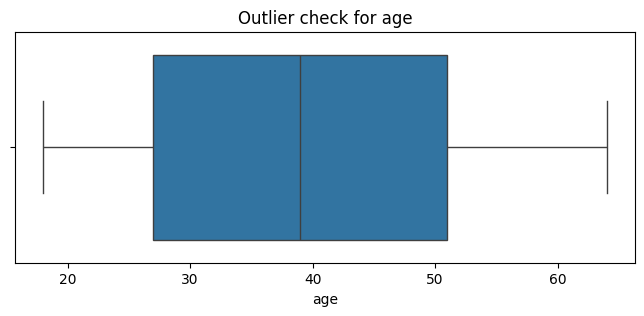

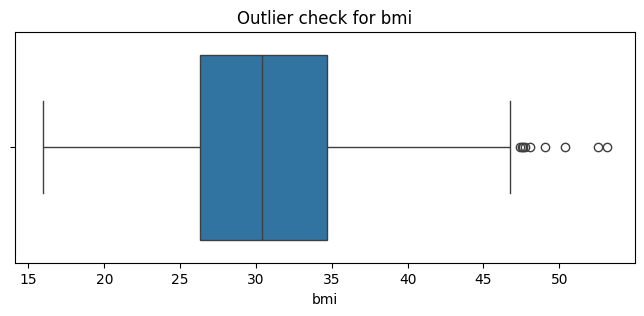

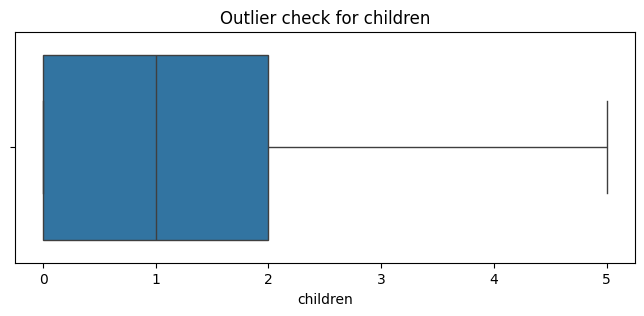

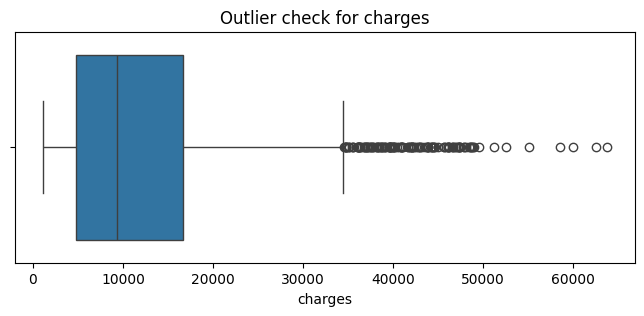

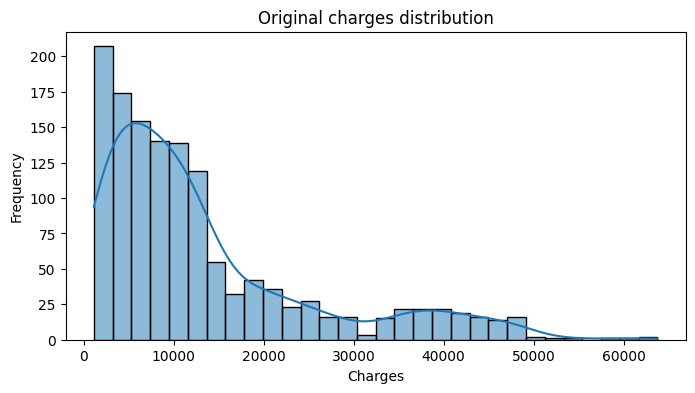

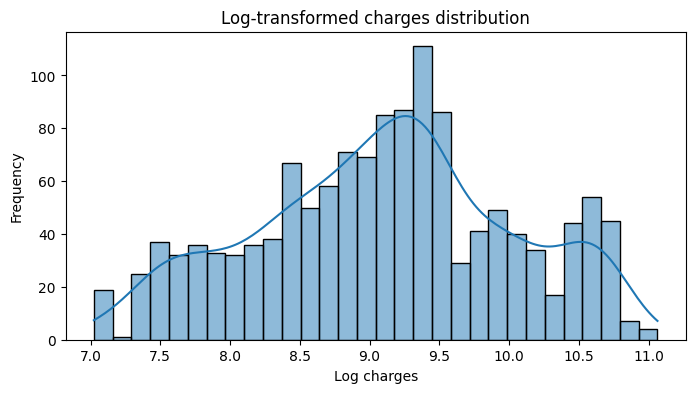

In [11]:
numerical_cols = ["age", "bmi", "children", "charges"]

print("Skewness of numerical columns:")
skewness_summary = df_clean[numerical_cols].skew().sort_values(ascending=False)
display(skewness_summary.round(3))

# Compare original charges vs log-transformed charges
df_eda = df_clean.copy()
df_eda["log_charges"] = np.log1p(df_eda["charges"])

print("\nCharges skewness before and after log transformation:")
print("Original charges skewness:", round(df_eda["charges"].skew(), 3))
print("Log charges skewness:", round(df_eda["log_charges"].skew(), 3))

# IQR outlier summary
outlier_summary = []

for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    outlier_percentage = (outlier_count / len(df_clean)) * 100
    
    outlier_summary.append({
        "feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percentage": outlier_percentage
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

print("\nIQR outlier summary:")
display(outlier_summary_df.round(2))

# Boxplots for numerical columns
for col in numerical_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_clean[col])
    plt.title(f"Outlier check for {col}")
    plt.xlabel(col)
    plt.show()

# Original charges vs log charges distribution
plt.figure(figsize=(8, 4))
sns.histplot(df_eda["charges"], kde=True, bins=30)
plt.title("Original charges distribution")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_eda["log_charges"], kde=True, bins=30)
plt.title("Log-transformed charges distribution")
plt.xlabel("Log charges")
plt.ylabel("Frequency")
plt.show()

### Skewness and outlier treatment decision

The skewness and outlier analysis was performed on the numerical variables: `age`, `bmi`, `children`, and `charges`.

Key findings:

- `charges` is strongly right-skewed, with a skewness value of approximately 1.52.
- After applying log transformation, the skewness of `charges` reduces to approximately -0.09, making the distribution much closer to normal.
- `bmi` shows only mild skewness, around 0.28.
- `children` shows moderate skewness, around 0.94, which is expected because it is a discrete count variable.
- `age` is almost symmetric and does not require transformation.

Outlier findings:

- `charges` has 139 upper-side outliers, representing around 10.40% of the cleaned dataset.
- `bmi` has 9 upper-side outliers, representing around 0.67% of the cleaned dataset.
- `age` and `children` do not show outliers using the IQR method.

Treatment decision:

The outliers will be retained.

This decision is appropriate because high insurance charges may represent valid high-cost medical cases, not data-entry errors. Similarly, high BMI values may represent valid patient profiles. Removing or capping these values could weaken the model’s ability to learn high-cost insurance patterns, which are important for this business problem.

Instead of removing outliers, the project will handle skewness and extreme values through the modeling strategy:

- Compare models trained on original `charges` with models trained on log-transformed `charges`.
- Use tree-based and ensemble models that can capture non-linear patterns.
- Apply feature scaling only where required, especially for SVR and KNN.
- Perform residual and error analysis later to check whether the model struggles with high-cost cases.

Final decision: no row removal, no capping, and no outlier treatment will be applied at this stage.

---

## Feature engineering

Based on EDA, age, BMI, and smoking status show meaningful relationships with insurance charges.

In this step, we create additional features to support model learning and management-level segment insights:

- `age_group`: groups customers into age bands
- `bmi_category`: groups BMI into standard BMI categories
- `smoker_bmi_interaction`: captures the combined effect of smoking status and BMI

The original numerical variables `age` and `bmi` are retained because they contain precise continuous information useful for model training.

In [12]:
df_model = df_clean.copy()

# Create age groups
df_model["age_group"] = pd.cut(
    df_model["age"],
    bins=[17, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-64"]
)

# Create BMI categories
df_model["bmi_category"] = pd.cut(
    df_model["bmi"],
    bins=[0, 18.5, 25, 30, 35, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese I", "Obese II+"]
)

# Create smoker-BMI interaction feature
df_model["smoker_bmi_interaction"] = df_model["smoker"] + "_" + df_model["bmi_category"].astype(str)

# Validate engineered dataset
print("Original cleaned dataset shape:")
print(df_clean.shape)

print("\nModeling dataset shape after feature engineering:")
print(df_model.shape)

print("\nNew columns added:")
new_columns = [col for col in df_model.columns if col not in df_clean.columns]
print(new_columns)

print("\nMissing values after feature engineering:")
display(df_model.isnull().sum())

print("\nAge group distribution:")
display(df_model["age_group"].value_counts().sort_index())

print("\nBMI category distribution:")
display(df_model["bmi_category"].value_counts().sort_index())

print("\nSmoker-BMI interaction distribution:")
display(df_model["smoker_bmi_interaction"].value_counts())

print("\nPreview of engineered dataset:")
display(df_model.head())

Original cleaned dataset shape:
(1337, 7)

Modeling dataset shape after feature engineering:
(1337, 10)

New columns added:
['age_group', 'bmi_category', 'smoker_bmi_interaction']

Missing values after feature engineering:


age                       0
sex                       0
bmi                       0
children                  0
smoker                    0
region                    0
charges                   0
age_group                 0
bmi_category              0
smoker_bmi_interaction    0
dtype: int64


Age group distribution:


age_group
18-25    305
26-35    268
36-45    264
46-55    284
56-64    216
Name: count, dtype: int64


BMI category distribution:


bmi_category
Underweight     21
Normal         226
Overweight     386
Obese I        388
Obese II+      316
Name: count, dtype: int64


Smoker-BMI interaction distribution:


smoker_bmi_interaction
no_Obese I         315
no_Overweight      311
no_Obese II+       245
no_Normal          176
yes_Overweight      75
yes_Obese I         73
yes_Obese II+       71
yes_Normal          50
no_Underweight      16
yes_Underweight      5
Name: count, dtype: int64


Preview of engineered dataset:


,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category,smoker_bmi_interaction
0,19,female,27.900,0,yes,southwest,16884.92400,18-25,Overweight,yes_Overweight
1,18,male,33.770,1,no,southeast,1725.55230,18-25,Obese I,no_Obese I
2,28,male,33.000,3,no,southeast,4449.46200,26-35,Obese I,no_Obese I
3,33,male,22.705,0,no,northwest,21984.47061,26-35,Normal,no_Normal
4,32,male,28.880,0,no,northwest,3866.85520,26-35,Overweight,no_Overweight


### Feature engineering validation and insights

Three engineered features were created from the cleaned dataset:

- `age_group`
- `bmi_category`
- `smoker_bmi_interaction`

The engineered dataset now contains 1,337 rows and 10 columns. No missing values were introduced during feature engineering.

Feature engineering decisions:

- `age_group` was created to capture age-based cost patterns observed during EDA.
- `bmi_category` was created to capture segment-level BMI risk patterns.
- `smoker_bmi_interaction` was created because EDA showed that smokers with higher BMI categories have significantly higher average insurance charges.

Important observations:

- Age groups are reasonably distributed across the dataset.
- BMI categories are mostly well represented, but the Underweight group has only 21 records.
- The `yes_Underweight` smoker-BMI interaction segment has only 5 records, so it should not be used for strong business conclusions.
- The engineered features are useful for both model experimentation and management-level segment analysis.

Modeling decision:

The original continuous variables `age` and `bmi` will be retained because they contain precise numerical information. The engineered features will be included initially, but model performance will be evaluated carefully to confirm whether they improve prediction accuracy without adding unnecessary complexity.

----

## Train-test split

Before applying encoding or scaling, the dataset is split into training and testing sets.

This prevents data leakage because preprocessing steps such as scaling and encoding must be fitted only on the training data and then applied to the test data.

The target variable is `charges`.

In [13]:
# Train-test split with target bin stratification
from sklearn.model_selection import train_test_split

# Define target variable
target = "charges"

# Define input features and target
X = df_model.drop(columns=[target])
y = df_model[target]

# Create temporary target bins for stratified splitting
# This helps preserve the distribution of low, medium, and high charges in train and test sets - after multiple experimments.
y_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

# Train-test split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_bins
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target summary:")
display(y_train.describe())

print("\nTesting target summary:")
display(y_test.describe())

print("\nTraining target percentiles:")
display(y_train.quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).round(2))

print("\nTesting target percentiles:")
display(y_test.quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).round(2))

print("\nInput feature columns:")
print(X_train.columns.tolist())

X_train shape: (1069, 9)
X_test shape: (268, 9)
y_train shape: (1069,)
y_test shape: (268,)

Training target summary:


count     1069.000000
mean     13291.224797
std      12086.375917
min       1121.873900
25%       4718.203550
50%       9432.925300
75%      16577.779500
max      60021.398970
Name: charges, dtype: float64


Testing target summary:


count      268.000000
mean     13230.843730
std      12228.184218
min       1135.940700
25%       4908.794762
50%       8967.062875
75%      17105.480600
max      63770.428010
Name: charges, dtype: float64


Training target percentiles:


0.25     4718.20
0.50     9432.93
0.75    16577.78
0.90    35150.05
0.95    41821.89
0.99    48283.51
Name: charges, dtype: float64


Testing target percentiles:


0.25     4908.79
0.50     8967.06
0.75    17105.48
0.90    34115.81
0.95    39910.22
0.99    49966.26
Name: charges, dtype: float64


Input feature columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'age_group', 'bmi_category', 'smoker_bmi_interaction']


### Train-test split validation

The dataset was split into training and testing sets using an 80:20 split.

Because the target variable `charges` is continuous and strongly right-skewed, a simple random split may create an uneven distribution of low-cost and high-cost records between the training and testing datasets.
To reduce this risk, the target variable was temporarily divided into quantile-based charge bands using `pd.qcut()`. These bands were used only for stratified splitting and were not included as model features.
This approach helps preserve a similar distribution of low, medium, and high insurance charges in both the training and testing sets.

The final split contains:

- 1,069 records in the training set
- 268 records in the testing set
- 9 input features
- 1 target variable: `charges`

No encoding, scaling, or transformation was fitted before the split, which helps prevent data leakage.

---

## Preprocessing setup for model pipelines

The dataset contains both numerical and categorical input features.

A `ColumnTransformer` is defined to apply preprocessing during model training:

- Numerical features will be scaled using `StandardScaler`.
- Categorical features will be encoded using `OneHotEncoder`.

The transformer is not fitted separately in this step. It will be fitted inside each sklearn Pipeline during model training to avoid duplicate preprocessing logic and reduce deployment mismatch risk.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define numerical and categorical features
numeric_features = ["age", "bmi", "children"]

categorical_features = [
    "sex",
    "smoker",
    "region",
    "age_group",
    "bmi_category",
    "smoker_bmi_interaction"
]

# Validate that all selected features exist in X_train
expected_features = numeric_features + categorical_features
missing_features = [col for col in expected_features if col not in X_train.columns]

if len(missing_features) == 0:
    print("All preprocessing features are present in X_train.")
else:
    print("Missing features:", missing_features)

# Create preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False), categorical_features)
    ],
    remainder="drop"
)

print("Preprocessor created successfully.")
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

All preprocessing features are present in X_train.
Preprocessor created successfully.
Numerical features: ['age', 'bmi', 'children']
Categorical features: ['sex', 'smoker', 'region', 'age_group', 'bmi_category', 'smoker_bmi_interaction']


### Preprocessing setup validation

The preprocessing setup was created successfully.
The selected numerical and categorical features are present in the training data. The `ColumnTransformer` will be used inside sklearn Pipelines during model training so that preprocessing and model prediction remain consistent.
The preprocessor was not fitted separately at this stage. This avoids duplicate preprocessing steps and reduces the risk of mismatch between notebook training and Streamlit deployment.

----

## Baseline model training on original charges

Multiple supervised regression models are trained using sklearn Pipelines.

Each pipeline includes:

- preprocessing through `ColumnTransformer`
- regression model training
- train and test evaluation

The models are evaluated using MAE, MSE, RMSE, R², and Adjusted R². Train and test performance are compared to identify possible overfitting.

In [15]:
# 1. Baseline model training on original charges

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# 2. Adjusted R2 calculation
def adjusted_r2_score(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# 3. Define baseline models required for the assignment
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "SVR": SVR(),
    "KNN Regressor": KNeighborsRegressor(),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

# 4. Train and evaluate models
results = []

for model_name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    p = len(pipeline.named_steps["preprocessor"].get_feature_names_out())
    
    train_adj_r2 = adjusted_r2_score(train_r2, len(y_train), p)
    test_adj_r2 = adjusted_r2_score(test_r2, len(y_test), p)
    
    r2_gap = train_r2 - test_r2
    rmse_gap = test_rmse - train_rmse
    
    if r2_gap > 0.15:
        overfitting_status = "High"
    elif r2_gap > 0.07:
        overfitting_status = "Moderate"
    else:
        overfitting_status = "Low"
    
    results.append({
        "Model": model_name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Train Adjusted R2": train_adj_r2,
        "Test Adjusted R2": test_adj_r2,
        "R2 Gap": r2_gap,
        "RMSE Gap": rmse_gap,
        "Overfitting Status": overfitting_status
    })

# 5. Create comparison table
baseline_results = pd.DataFrame(results)

# 6. Sort by best Test RMSE
baseline_results = baseline_results.sort_values(
    by="Test RMSE",
    ascending=True
).reset_index(drop=True)

# 7. Display rounded results
display(baseline_results.round(4))

,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,R2 Gap,RMSE Gap,Overfitting Status
0,Linear Regression,2301.1418,2510.9251,1.823266e+07,2.187578e+07,4269.9720,4677.1552,0.8751,0.8532,0.8721,0.8380,0.0219,407.1832,Low
1,Random Forest Regressor,993.7480,2858.8181,3.194602e+06,2.595530e+07,1787.3449,5094.6347,0.9781,0.8258,0.9776,0.8078,0.1523,3307.2897,High
2,Gradient Boosting Regressor,2005.1733,2877.1192,1.366977e+07,2.641020e+07,3697.2650,5139.0854,0.9063,0.8227,0.9041,0.8044,0.0836,1441.8204,Moderate
3,KNN Regressor,2293.8279,3261.1037,1.632588e+07,3.264469e+07,4040.5303,5713.5534,0.8881,0.7809,0.8855,0.7582,0.1073,1673.0231,Moderate
4,Decision Tree Regressor,11.6943,3364.1856,7.309655e+04,4.839639e+07,270.3637,6956.7512,0.9995,0.6751,0.9995,0.6416,0.3244,6686.3875,High
5,SVR,8330.3858,8296.0757,1.604889e+08,1.631661e+08,12668.4195,12773.6492,-0.0997,-0.0953,-0.1260,-0.2084,-0.0044,105.2298,Low


### Baseline model training insights

Multiple regression models were trained and evaluated on the original `charges` target variable using sklearn Pipelines.

Key observations:

- Linear Regression gives the best baseline test performance, with the lowest Test RMSE of around 4,677 and the highest Test R² of around 0.853.
- Linear Regression also shows low overfitting, with a small gap between train and test R².
- Random Forest performs very well on the training data but drops on the test data. This indicates high overfitting.
- Decision Tree shows severe overfitting. It almost perfectly fits the training data but performs much worse on the test data.
- Gradient Boosting performs reasonably well but still shows moderate overfitting.
- KNN performs moderately but is weaker than Linear Regression and ensemble models.
- SVR performs poorly, with negative R², meaning it is worse than a simple mean-based prediction for this setup.

Baseline decision:

Linear Regression is currently the strongest baseline model because it provides the best test performance with low overfitting. However, because the target variable `charges` is highly skewed, the next step is to compare model performance using log-transformed charges before selecting or tuning the final model.

----

## Log-transformed target modeling

The target variable `charges` is strongly right-skewed. To check whether target transformation improves prediction performance, the same baseline model set is trained again using log-transformed charges.
`TransformedTargetRegressor` is used so that the model learns on `log1p(charges)` and predictions are automatically converted back to the original charge scale using `expm1`.
This allows a fair comparison between original-target modeling and log-target modeling using the same regression models.

In [16]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.base import clone

required_objects = [
    "models",
    "preprocessor",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "adjusted_r2_score"
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise NameError(f"Missing required objects: {missing_objects}. Run the mandatory previous cells first.")

log_results = []
log_trained_pipelines = {}

for model_name, model in models.items():
    
    base_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", clone(model))
    ])
    
    log_pipeline = TransformedTargetRegressor(
        regressor=base_pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )
    
    log_pipeline.fit(X_train, y_train)
    
    y_train_pred = log_pipeline.predict(X_train)
    y_test_pred = log_pipeline.predict(X_test)
    
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    p = len(log_pipeline.regressor_.named_steps["preprocessor"].get_feature_names_out())
    
    train_adj_r2 = adjusted_r2_score(train_r2, len(y_train), p)
    test_adj_r2 = adjusted_r2_score(test_r2, len(y_test), p)
    
    r2_gap = train_r2 - test_r2
    rmse_gap = test_rmse - train_rmse
    
    if r2_gap > 0.15:
        overfitting_status = "High"
    elif r2_gap > 0.07:
        overfitting_status = "Moderate"
    else:
        overfitting_status = "Low"
    
    log_results.append({
        "Model": model_name + " - Log Target",
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Train Adjusted R2": train_adj_r2,
        "Test Adjusted R2": test_adj_r2,
        "R2 Gap": r2_gap,
        "RMSE Gap": rmse_gap,
        "Overfitting Status": overfitting_status
    })
    
    log_trained_pipelines[model_name + " - Log Target"] = log_pipeline

log_results = pd.DataFrame(log_results)

log_results = log_results.sort_values(
    by="Test RMSE",
    ascending=True
).reset_index(drop=True)

display(log_results.round(4))

,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,R2 Gap,RMSE Gap,Overfitting Status
0,Random Forest Regressor - Log Target,929.2746,2365.2635,5.022814e+06,2.404610e+07,2241.1636,4903.6827,0.9656,0.8386,0.9648,0.8219,0.1270,2662.5191,Moderate
1,Gradient Boosting Regressor - Log Target,1812.5448,2378.3228,1.587073e+07,2.478059e+07,3983.8079,4978.0109,0.8913,0.8337,0.8886,0.8165,0.0576,994.2030,Low
2,SVR - Log Target,1946.4129,2483.5345,1.827252e+07,3.006098e+07,4274.6371,5482.7897,0.8748,0.7982,0.8718,0.7774,0.0766,1208.1526,Moderate
3,KNN Regressor - Log Target,2151.7816,2842.3909,1.879572e+07,3.417110e+07,4335.4026,5845.6050,0.8712,0.7706,0.8681,0.7469,0.1006,1510.2023,Moderate
4,Decision Tree Regressor - Log Target,11.6943,3139.2541,9.083822e+04,4.163520e+07,301.3938,6452.5342,0.9994,0.7205,0.9994,0.6916,0.2789,6151.1404,High
5,Linear Regression - Log Target,3979.9123,3825.6371,6.791651e+07,6.272319e+07,8241.1476,7919.7974,0.5346,0.5790,0.5235,0.5355,-0.0443,-321.3502,Low


### Log-transformed target modeling insights

The same baseline model set was trained again using log-transformed `charges`.

Key observations:

- Random Forest Regressor gives the best log-target performance, with Test RMSE around 4,904 and Test R² around 0.839.
- Gradient Boosting Regressor also performs well, with Test RMSE around 4,978 and Test R² around 0.834.
- Log transformation improves some non-linear models, but it does not improve Linear Regression.
- Linear Regression performs much worse with log-transformed target compared with original charges.
- Decision Tree continues to show high overfitting even after log transformation.
- SVR improves compared with its original-target version, but it is still not among the best-performing models.

Decision:

Log-transformed modeling is useful for comparison, but the best overall baseline result is still from Linear Regression trained on original `charges`. The next step is to create a combined comparison table for original-target and log-target models before selecting models for tuning.

----

## Original vs log-transformed model comparison

The baseline models trained on original `charges` are compared with the same model set trained on log-transformed `charges`.
This comparison helps identify whether target transformation improved model performance and which models should be shortlisted for hyperparameter tuning.

In [17]:
# Combined comparison: original target vs log-transformed target. This is also after resolving the overfitting issue with the log-transformed target and resolving errors in this notebook

# Safety check
required_objects = ["baseline_results", "log_results"]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise NameError(f"Missing required objects: {missing_objects}. Run baseline and log-target model cells first.")

baseline_compare = baseline_results.copy()
log_compare = log_results.copy()

baseline_compare["Target Approach"] = "Original charges"
log_compare["Target Approach"] = "Log-transformed charges"

# Combine both result tables
combined_results = pd.concat(
    [baseline_compare, log_compare],
    ignore_index=True
)

# Select key comparison columns
combined_results_summary = combined_results[
    [
        "Target Approach",
        "Model",
        "Train RMSE",
        "Test RMSE",
        "Train R2",
        "Test R2",
        "Train Adjusted R2",
        "Test Adjusted R2",
        "R2 Gap",
        "RMSE Gap",
        "Overfitting Status"
    ]
].copy()

# Sort by Test RMSE
combined_results_summary = combined_results_summary.sort_values(
    by="Test RMSE",
    ascending=True
).reset_index(drop=True)

display(combined_results_summary.round(4))

,Target Approach,Model,Train RMSE,Test RMSE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,R2 Gap,RMSE Gap,Overfitting Status
0,Original charges,Linear Regression,4269.9720,4677.1552,0.8751,0.8532,0.8721,0.8380,0.0219,407.1832,Low
1,Log-transformed charges,Random Forest Regressor - Log Target,2241.1636,4903.6827,0.9656,0.8386,0.9648,0.8219,0.1270,2662.5191,Moderate
2,Log-transformed charges,Gradient Boosting Regressor - Log Target,3983.8079,4978.0109,0.8913,0.8337,0.8886,0.8165,0.0576,994.2030,Low
3,Original charges,Random Forest Regressor,1787.3449,5094.6347,0.9781,0.8258,0.9776,0.8078,0.1523,3307.2897,High
4,Original charges,Gradient Boosting Regressor,3697.2650,5139.0854,0.9063,0.8227,0.9041,0.8044,0.0836,1441.8204,Moderate
5,Log-transformed charges,SVR - Log Target,4274.6371,5482.7897,0.8748,0.7982,0.8718,0.7774,0.0766,1208.1526,Moderate
6,Original charges,KNN Regressor,4040.5303,5713.5534,0.8881,0.7809,0.8855,0.7582,0.1073,1673.0231,Moderate
7,Log-transformed charges,KNN Regressor - Log Target,4335.4026,5845.6050,0.8712,0.7706,0.8681,0.7469,0.1006,1510.2023,Moderate
8,Log-transformed charges,Decision Tree Regressor - Log Target,301.3938,6452.5342,0.9994,0.7205,0.9994,0.6916,0.2789,6151.1404,High
9,Original charges,Decision Tree Regressor,270.3637,6956.7512,0.9995,0.6751,0.9995,0.6416,0.3244,6686.3875,High


### Original vs log-transformed model comparison insights

The combined comparison shows that the best overall model before tuning is Linear Regression trained on original `charges`.

Key observations:

- Original Linear Regression has the best test performance, with Test RMSE around 4,677 and Test R² around 0.853.
- Log transformation improves some non-linear models, especially Random Forest and Gradient Boosting, but it does not beat original Linear Regression.
- Random Forest with log target is the second-best model by Test RMSE, but it still shows moderate overfitting.
- Gradient Boosting with log target gives stable performance with low overfitting and is close to Random Forest.
- Decision Tree performs poorly because it heavily overfits in both original and log-target versions.
- Original SVR performs the worst, with negative Test R². Log transformation improves SVR, but it still does not become a top model.

Modeling decision:

For hyperparameter tuning, the strongest candidates are:

1. Linear Regression as the current best baseline reference.
2. Random Forest Regressor with log-transformed target.
3. Gradient Boosting Regressor with log-transformed target.

Decision Tree and SVR should not be prioritized for tuning because their performance is weaker or unstable.

---

## Hyperparameter tuning

Based on the combined model comparison, the strongest tunable candidates are selected for hyperparameter tuning.
Linear Regression is kept as the benchmark because it has the best baseline result but does not have meaningful hyperparameters to tune.
The tuned models are:

- Random Forest Regressor with log-transformed target
- Gradient Boosting Regressor with log-transformed target

RandomizedSearchCV is used with cross-validation to identify better hyperparameter combinations.

In [19]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Helper function for overfitting status
def get_overfitting_status(train_r2, test_r2):
    r2_gap = train_r2 - test_r2
    
    if r2_gap > 0.15:
        return "High"
    elif r2_gap > 0.07:
        return "Moderate"
    else:
        return "Low"

# Shortlisted models for tuning
tuning_candidates = {
    "Random Forest Regressor - Log Target": {
        "estimator": TransformedTargetRegressor(
            regressor=Pipeline(steps=[
                ("preprocessor", preprocessor),
                ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
            ]),
            func=np.log1p,
            inverse_func=np.expm1
        ),
        "params": {
            "regressor__model__n_estimators": [100, 200, 300],
            "regressor__model__max_depth": [3, 5, 7, 10],
            "regressor__model__min_samples_split": [2, 5, 10],
            "regressor__model__min_samples_leaf": [1, 2, 4],
            "regressor__model__max_features": ["sqrt", "log2", 1.0]
        }
    },
    
    "Gradient Boosting Regressor - Log Target": {
        "estimator": TransformedTargetRegressor(
            regressor=Pipeline(steps=[
                ("preprocessor", preprocessor),
                ("model", GradientBoostingRegressor(random_state=42))
            ]),
            func=np.log1p,
            inverse_func=np.expm1
        ),
        "params": {
            "regressor__model__n_estimators": [100, 200, 300],
            "regressor__model__learning_rate": [0.03, 0.05, 0.1],
            "regressor__model__max_depth": [2, 3, 4],
            "regressor__model__min_samples_split": [2, 5, 10],
            "regressor__model__min_samples_leaf": [1, 2, 4],
            "regressor__model__subsample": [0.8, 1.0]
        }
    }
}

tuned_results = []
tuned_models = {}

for model_name, config in tuning_candidates.items():
    
    search = RandomizedSearchCV(
        estimator=config["estimator"],
        param_distributions=config["params"],
        n_iter=10,
        scoring="neg_root_mean_squared_error",
        cv=3,
        random_state=42,
        n_jobs=1
    )
    
    search.fit(X_train, y_train)
    
    best_model = search.best_estimator_
    
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    p = len(best_model.regressor_.named_steps["preprocessor"].get_feature_names_out())
    
    baseline_row = combined_results_summary[
        combined_results_summary["Model"] == model_name
    ].iloc[0]
    
    baseline_test_rmse = baseline_row["Test RMSE"]
    baseline_test_r2 = baseline_row["Test R2"]
    
    tuned_results.append({
        "Model": "Tuned " + model_name,
        "Baseline Test RMSE": baseline_test_rmse,
        "Tuned Test RMSE": test_rmse,
        "RMSE Improvement": baseline_test_rmse - test_rmse,
        "Baseline Test R2": baseline_test_r2,
        "Tuned Test R2": test_r2,
        "Train RMSE": train_rmse,
        "Train R2": train_r2,
        "Test Adjusted R2": adjusted_r2_score(test_r2, len(y_test), p),
        "Best CV RMSE": -search.best_score_,
        "Overfitting Status": get_overfitting_status(train_r2, test_r2),
        "Best Parameters": search.best_params_
    })
    
    tuned_models["Tuned " + model_name] = best_model

tuned_results = pd.DataFrame(tuned_results)

tuned_results = tuned_results.sort_values(
    by="Tuned Test RMSE",
    ascending=True
).reset_index(drop=True)

display(tuned_results.round(4))

,Model,Baseline Test RMSE,Tuned Test RMSE,RMSE Improvement,Baseline Test R2,Tuned Test R2,Train RMSE,Train R2,Test Adjusted R2,Best CV RMSE,Overfitting Status,Best Parameters
0,Tuned Random Forest Regressor - Log Target,4903.6827,4881.8554,21.8273,0.8386,0.8400,4111.1465,0.8842,0.8235,4435.1063,Low,"{'regressor__model__n_estimators': 300, 'regre..."
1,Tuned Gradient Boosting Regressor - Log Target,4978.0109,4925.1912,52.8197,0.8337,0.8372,4181.8202,0.8802,0.8203,4471.5870,Low,"{'regressor__model__subsample': 1.0, 'regresso..."


### Why Linear Regression was not hyperparameter-tuned

Linear Regression was not included in hyperparameter tuning because the basic Linear Regression model does not have major model-complexity hyperparameters like tree depth, number of estimators, learning rate, or minimum samples split.

At this stage, Linear Regression is kept as the benchmark model because it gave the best baseline test performance with low overfitting. Hyperparameter tuning is applied to Random Forest and Gradient Boosting because these ensemble models have tunable parameters that can control model complexity and reduce overfitting.


### Hyperparameter tuning insights
Hyperparameter tuning was performed on the two strongest tunable candidates from the combined model comparison:

- Random Forest Regressor with log-transformed target
- Gradient Boosting Regressor with log-transformed target

Key observations:

- Tuned Random Forest Regressor achieved the best tuned performance, with Test RMSE improving from around 4,904 to around 4,882.
- Tuned Gradient Boosting Regressor also improved, with Test RMSE reducing from around 4,978 to around 4,925.
- Both tuned models show low overfitting after hyperparameter tuning.
- Random Forest remains slightly better than Gradient Boosting after tuning.
- The improvement from tuning is positive but modest.
- Even after tuning, both log-target ensemble models are still slightly weaker than the original Linear Regression baseline, which had Test RMSE around 4,677 and Test R² around 0.853.

Modeling decision:

Hyperparameter tuning improved the shortlisted ensemble models, but the tuned models do not currently outperform the original Linear Regression baseline. Therefore, the final model selection should be based on the complete final comparison table, considering Test RMSE, Test R², adjusted R², overfitting status, and model simplicity.

---

## Best parameters and tuning improvement

In [20]:
tuning_summary = tuned_results[
    [
        "Model",
        "Baseline Test RMSE",
        "Tuned Test RMSE",
        "RMSE Improvement",
        "Baseline Test R2",
        "Tuned Test R2",
        "Best CV RMSE",
        "Overfitting Status"
    ]
].copy()

display(tuning_summary.round(4))

print("Best hyperparameters selected during tuning:\n")

for index, row in tuned_results.iterrows():
    print(row["Model"])
    print("-" * len(row["Model"]))
    
    for param, value in row["Best Parameters"].items():
        print(f"{param}: {value}")
    
    print()

,Model,Baseline Test RMSE,Tuned Test RMSE,RMSE Improvement,Baseline Test R2,Tuned Test R2,Best CV RMSE,Overfitting Status
0,Tuned Random Forest Regressor - Log Target,4903.6827,4881.8554,21.8273,0.8386,0.8400,4435.1063,Low
1,Tuned Gradient Boosting Regressor - Log Target,4978.0109,4925.1912,52.8197,0.8337,0.8372,4471.5870,Low


Best hyperparameters selected during tuning:

Tuned Random Forest Regressor - Log Target
------------------------------------------
regressor__model__n_estimators: 300
regressor__model__min_samples_split: 2
regressor__model__min_samples_leaf: 1
regressor__model__max_features: 1.0
regressor__model__max_depth: 5

Tuned Gradient Boosting Regressor - Log Target
----------------------------------------------
regressor__model__subsample: 1.0
regressor__model__n_estimators: 100
regressor__model__min_samples_split: 10
regressor__model__min_samples_leaf: 1
regressor__model__max_depth: 3
regressor__model__learning_rate: 0.05



**Conclusion:**

Hyperparameter tuning improved the shortlisted ensemble models, but the final model should be selected using the final comparison table across baseline, log-transformed, and tuned models.

----

## Cross-validation for final shortlisted models

To avoid selecting the final model based only on one train-test split, 5-fold cross-validation is performed on the shortlisted models. The comparison uses average CV RMSE and CV R² to check which model performs more consistently across different data folds.

In [23]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# 5-fold cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Shortlisted models:
# 1. Original Linear Regression baseline
# 2. Tuned Random Forest with log-transformed target
# 3. Tuned Gradient Boosting with log-transformed target

cv_candidates = {
    "Linear Regression - Original Charges": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),
    "Tuned Random Forest Regressor - Log Target": tuned_models["Tuned Random Forest Regressor - Log Target"],
    "Tuned Gradient Boosting Regressor - Log Target": tuned_models["Tuned Gradient Boosting Regressor - Log Target"]
}

cv_results = []

for model_name, model in cv_candidates.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        },
        n_jobs=-1,
        return_train_score=False
    )
    
    cv_results.append({
        "Model": model_name,
        "Mean CV RMSE": -scores["test_rmse"].mean(),
        "CV RMSE Std": scores["test_rmse"].std(),
        "Mean CV R2": scores["test_r2"].mean(),
        "CV R2 Std": scores["test_r2"].std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by="Mean CV RMSE",
    ascending=True
).reset_index(drop=True)

display(cv_results_df.round(4))

,Model,Mean CV RMSE,CV RMSE Std,Mean CV R2,CV R2 Std
0,Linear Regression - Original Charges,4375.7356,511.2864,0.8642,0.0439
1,Tuned Random Forest Regressor - Log Target,4394.3344,589.1371,0.8622,0.0495
2,Tuned Gradient Boosting Regressor - Log Target,4449.9117,494.6389,0.8596,0.0442


### Cross-validation insight

The 5-fold cross-validation results support the final model selection. Linear Regression trained on original charges gives the best average cross-validation performance, with the lowest Mean CV RMSE of around 4,376 and the highest Mean CV R² of around 0.864.

The tuned Random Forest Regressor with log-transformed target performs very close to Linear Regression, but does not outperform it. Tuned Gradient Boosting also performs well but has a slightly higher average CV RMSE.
This confirms that Linear Regression is not selected only because of one train-test split. It also performs consistently across multiple folds, while remaining simpler, more interpretable, and suitable for deployment

Note: Regularized linear models such as Ridge, Lasso, and ElasticNet can be explored as future improvements if stronger regularization or feature selection is required. They were not added in this project because the selected Linear Regression model already showed low overfitting and was confirmed through cross-validation.

---

## Final model comparison and selection

The final comparison combines the best baseline, log-transformed, and tuned model results.
The final model is selected based on:

- Test RMSE
- Test R²
- Adjusted R²
- Overfitting status
- Model simplicity and deployment suitability

In [24]:
# 1. Baseline and log-target results
final_baseline_log = combined_results_summary.copy()
final_baseline_log["Model Stage"] = "Baseline / Log comparison"

# 2. Tuned model results converted to comparison format
final_tuned = tuned_results.copy()

# 3. Number of processed features used by tuned models
p_tuned = len(
    next(iter(tuned_models.values()))
    .regressor_
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

final_tuned_summary = pd.DataFrame({
    "Target Approach": ["Tuned log-transformed charges"] * len(final_tuned),
    "Model": final_tuned["Model"],
    "Train RMSE": final_tuned["Train RMSE"],
    "Test RMSE": final_tuned["Tuned Test RMSE"],
    "Train R2": final_tuned["Train R2"],
    "Test R2": final_tuned["Tuned Test R2"],
    "Train Adjusted R2": adjusted_r2_score(final_tuned["Train R2"], len(y_train), p_tuned),
    "Test Adjusted R2": final_tuned["Test Adjusted R2"],
    "R2 Gap": final_tuned["Train R2"] - final_tuned["Tuned Test R2"],
    "RMSE Gap": final_tuned["Tuned Test RMSE"] - final_tuned["Train RMSE"],
    "Overfitting Status": final_tuned["Overfitting Status"],
    "Model Stage": "Tuned model"
})

# 4. Combine all model results
final_model_comparison = pd.concat(
    [final_baseline_log, final_tuned_summary],
    ignore_index=True
)

# 5. Sort by Test RMSE
final_model_comparison = final_model_comparison.sort_values(
    by="Test RMSE",
    ascending=True
).reset_index(drop=True)

display(final_model_comparison.round(4))

,Target Approach,Model,Train RMSE,Test RMSE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,R2 Gap,RMSE Gap,Overfitting Status,Model Stage
0,Original charges,Linear Regression,4269.9720,4677.1552,0.8751,0.8532,0.8721,0.8380,0.0219,407.1832,Low,Baseline / Log comparison
1,Tuned log-transformed charges,Tuned Random Forest Regressor - Log Target,4111.1465,4881.8554,0.8842,0.8400,0.8814,0.8235,0.0442,770.7089,Low,Tuned model
2,Log-transformed charges,Random Forest Regressor - Log Target,2241.1636,4903.6827,0.9656,0.8386,0.9648,0.8219,0.1270,2662.5191,Moderate,Baseline / Log comparison
3,Tuned log-transformed charges,Tuned Gradient Boosting Regressor - Log Target,4181.8202,4925.1912,0.8802,0.8372,0.8773,0.8203,0.0430,743.3710,Low,Tuned model
4,Log-transformed charges,Gradient Boosting Regressor - Log Target,3983.8079,4978.0109,0.8913,0.8337,0.8886,0.8165,0.0576,994.2030,Low,Baseline / Log comparison
5,Original charges,Random Forest Regressor,1787.3449,5094.6347,0.9781,0.8258,0.9776,0.8078,0.1523,3307.2897,High,Baseline / Log comparison
6,Original charges,Gradient Boosting Regressor,3697.2650,5139.0854,0.9063,0.8227,0.9041,0.8044,0.0836,1441.8204,Moderate,Baseline / Log comparison
7,Log-transformed charges,SVR - Log Target,4274.6371,5482.7897,0.8748,0.7982,0.8718,0.7774,0.0766,1208.1526,Moderate,Baseline / Log comparison
8,Original charges,KNN Regressor,4040.5303,5713.5534,0.8881,0.7809,0.8855,0.7582,0.1073,1673.0231,Moderate,Baseline / Log comparison
9,Log-transformed charges,KNN Regressor - Log Target,4335.4026,5845.6050,0.8712,0.7706,0.8681,0.7469,0.1006,1510.2023,Moderate,Baseline / Log comparison


### Final model comparison insights

The final comparison shows that Linear Regression trained on original charges is the best-performing model overall.

Key observations:
- Original Linear Regression has the lowest Test RMSE of around 4,677 and the highest Test R² of around 0.853.
- It also shows low overfitting, with a small R² gap of around 0.022 between training and testing performance.
- 5-fold cross-validation further supports this selection, where Linear Regression achieved the lowest Mean CV RMSE of around 4,376 and the highest Mean CV R² of around 0.864 among the shortlisted final models.
- Tuned Random Forest with log-transformed target is the second-best model, with Test RMSE around 4,882 and Test R² around 0.840.
- Tuned Gradient Boosting with log-transformed target also performs well, but its Test RMSE is slightly higher than Tuned Random Forest.
- Hyperparameter tuning improved the log-target ensemble models, but the improvement was not enough to beat the original Linear Regression baseline.
- Decision Tree models show high overfitting and are not suitable as final models.
- SVR performs poorly on the original target and remains weaker than the top models even after log transformation.
- KNN gives moderate performance but does not outperform the best models.

**Final selection decision:**
Linear Regression trained on original charges is selected as the final model because it provides the best test-set performance, low overfitting, strong adjusted R², and the best cross-validation performance among the shortlisted models. It is also simpler, more interpretable, and suitable for deployment.

---

## Final model selection and model saving

Based on the final model comparison, Linear Regression trained on original `charges` is selected as the final model.

It is selected because it has:

- The lowest Test RMSE
- The highest Test R²
- Low overfitting
- Strong adjusted R²
- Simple and stable deployment behavior

The final model pipeline is saved so it can be reused in the Streamlit application.

In [25]:
import os
import joblib

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Selected final model: Linear Regression on original charges
final_model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

final_model_pipeline.fit(X_train, y_train)

y_train_pred_final = final_model_pipeline.predict(X_train)
y_test_pred_final = final_model_pipeline.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred_final)
test_mse = mean_squared_error(y_test, y_test_pred_final)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred_final)
test_r2 = r2_score(y_test, y_test_pred_final)

p = len(final_model_pipeline.named_steps["preprocessor"].get_feature_names_out())

final_model_metrics = pd.DataFrame([{
    "Final Model": "Linear Regression - Original Charges",
    "Train MAE": mean_absolute_error(y_train, y_train_pred_final),
    "Test MAE": mean_absolute_error(y_test, y_test_pred_final),
    "Train MSE": train_mse,
    "Test MSE": test_mse,
    "Train RMSE": train_rmse,
    "Test RMSE": test_rmse,
    "Train R2": train_r2,
    "Test R2": test_r2,
    "Train Adjusted R2": adjusted_r2_score(train_r2, len(y_train), p),
    "Test Adjusted R2": adjusted_r2_score(test_r2, len(y_test), p),
    "R2 Gap": train_r2 - test_r2,
    "Overfitting Status": "Low"
}])

display(final_model_metrics.round(4))

# Create artifacts folder
os.makedirs("artifacts", exist_ok=True)

# Save final model pipeline
joblib.dump(
    final_model_pipeline,
    "artifacts/final_medical_insurance_model.pkl"
)

# Save metadata needed for Streamlit prediction
model_metadata = {
    "model_name": "Linear Regression - Original Charges",
    "target": "charges",
    "input_features": X_train.columns.tolist(),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "test_rmse": test_rmse,
    "test_r2": test_r2,
    "note": "Before prediction, age_group, bmi_category, and smoker_bmi_interaction must be created exactly as done during feature engineering."
}

joblib.dump(
    model_metadata,
    "artifacts/model_metadata.pkl"
)

print("Final model pipeline saved at: artifacts/final_medical_insurance_model.pkl")
print("Model metadata saved at: artifacts/model_metadata.pkl")

,Final Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,R2 Gap,Overfitting Status
0,Linear Regression - Original Charges,2301.1418,2510.9251,1.823266e+07,2.187578e+07,4269.972,4677.1552,0.8751,0.8532,0.8721,0.838,0.0219,Low


Final model pipeline saved at: artifacts/final_medical_insurance_model.pkl
Model metadata saved at: artifacts/model_metadata.pkl
